# 1 month salt budget test for panant-01 control

This salt budget **does close**!  
This is from the experiment at /home/157/akm157/mom6/panant-01-zstar-ACCESSyr2/.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_1a = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output000/*.ocean_month.nc'))
paths_1b = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-test-pan01_test_01-f7e0ea96/output000/*.ocean_month_z.nc'))

paths_2a = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output001/*.ocean_month.nc'))
paths_2b = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-expt-3393fa55/output001/*.ocean_month_z.nc'))

In [3]:
# Time variant variables
def preprocess_a(ds):
    ds = ds[['wfo','lrunoff']].sel(yh=lat_slice)
    return ds

def preprocess_b(ds):
    ds = ds[['so','S_advection_xy','Sh_tendency_vert_remap','osalttend','osaltpmdiff','osaltdiff','boundary_forcing_salt_tendency']].sel(yh=lat_slice)
    return ds

pan_C = xr.open_mfdataset(paths_1a, preprocess = preprocess_a, chunks = 'auto')
pan_C_z = xr.open_mfdataset(paths_1b, preprocess = preprocess_b, chunks = 'auto')

pan_M = xr.open_mfdataset(paths_2a, preprocess = preprocess_a, chunks = 'auto')
pan_M_z = xr.open_mfdataset(paths_2b, preprocess = preprocess_b, chunks = 'auto')

In [4]:
lhs_salt_C = {
    'salt_tendency': pan_C_z.osalttend
}

rhs_salt_C = {
    # Advection
    'advection_xy': pan_C_z.S_advection_xy,
    'advection_vert': pan_C_z.Sh_tendency_vert_remap,

    # Diffusion / mixing
    'vertical_diffusion': pan_C_z.osaltdiff,
    'neutral_diffusion': pan_C_z.osaltpmdiff,

    # Surface & boundary forcing
    'surface_forcing': pan_C_z.boundary_forcing_salt_tendency,
}

lhs_salt_M = {
    'salt_tendency': pan_M_z.osalttend
}

rhs_salt_M = {
    # Advection
    'advection_xy': pan_M_z.S_advection_xy,
    'advection_vert': pan_M_z.Sh_tendency_vert_remap,

    # Diffusion / mixing
    'vertical_diffusion': pan_M_z.osaltdiff,
    'neutral_diffusion': pan_M_z.osaltpmdiff,

    # Surface & boundary forcing
    'surface_forcing': pan_M_z.boundary_forcing_salt_tendency,
}

At the moment taking `time`=0 to just look at first month - but I'm unsure this is still giving me the right evolution over time that I am looking for.

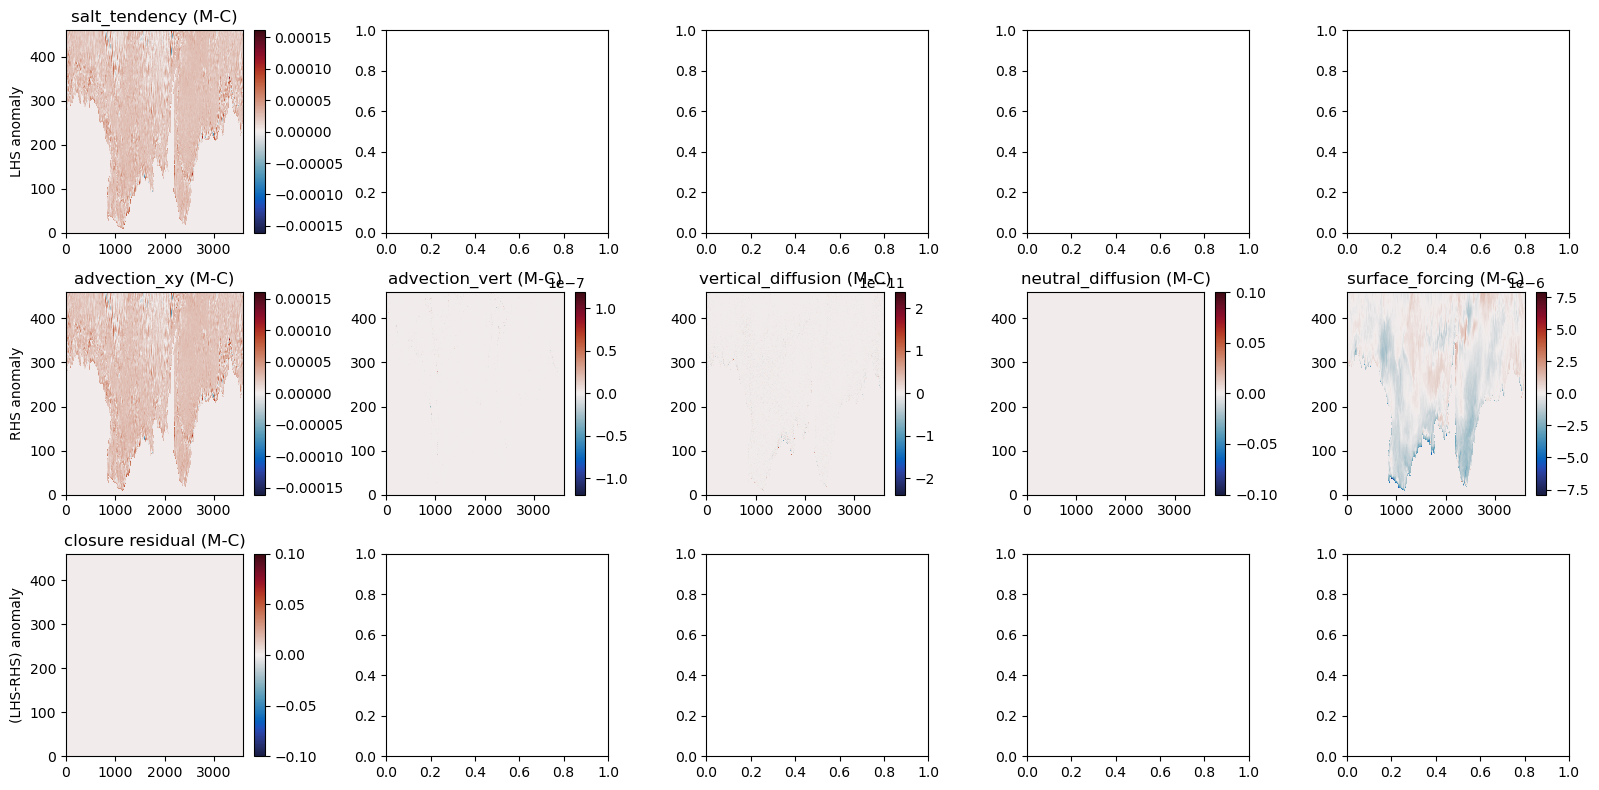

In [5]:
zdim = 'z_l'  # MOM6 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt_C), len(rhs_salt_C))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# ============================================================
# Helper: vertically integrate and select first time
# ============================================================
def prep(da):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    return da2d.compute()

# ============================================================
# LHS anomaly terms
# ============================================================
for i, name in enumerate(lhs_salt_C.keys()):
    
    da_C = prep(lhs_salt_C[name])
    da_M = prep(lhs_salt_M[name])
    
    anomaly = da_M - da_C
    
    vmax = np.nanmax(np.abs(anomaly))
    im = ax[0, i].pcolormesh(
        anomaly, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
    )
    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(f"{name} (M-C)")
    
# ============================================================
# RHS anomaly terms
# ============================================================
for i, name in enumerate(rhs_salt_C.keys()):
    
    da_C = prep(rhs_salt_C[name])
    da_M = prep(rhs_salt_M[name])
    
    anomaly = da_M - da_C
    
    vmax = np.nanmax(np.abs(anomaly))
    im = ax[1, i].pcolormesh(
        anomaly, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
    )
    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(f"{name} (M-C)")

# ============================================================
# Closure residual anomaly
# ============================================================

lhs_total_C = (
    pan_C_z.osalttend
)

rhs_total_C = (
    pan_C_z.S_advection_xy
    + pan_C_z.Sh_tendency_vert_remap
    + pan_C_z.boundary_forcing_salt_tendency
    + pan_C_z.osaltdiff
    + pan_C_z.osaltpmdiff
)

lhs_total_M = (
    pan_M_z.osalttend
)

rhs_total_M = (
    pan_M_z.S_advection_xy
    + pan_M_z.Sh_tendency_vert_remap
    + pan_M_z.boundary_forcing_salt_tendency
    + pan_M_z.osaltdiff
    + pan_M_z.osaltpmdiff
)

residual_anom = prep(lhs_total_M - rhs_total_M) - prep(lhs_total_C - rhs_total_C)

if 'time' in residual_anom.dims:
    residual_anom = residual_anom.isel(time=0)

residual_anom = residual_anom.compute()
vmax = np.abs(residual_anom).max()

im = ax[2, 0].pcolormesh(
    residual_anom, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
)
plt.colorbar(im, ax=ax[2, 0])
ax[2, 0].set_title('closure residual (M-C)')


# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS anomaly')
ax[1, 0].set_ylabel('RHS anomaly')
ax[2, 0].set_ylabel('(LHS-RHS) anomaly')

plt.tight_layout()


#### Checking if we have closure:   

In [6]:
residual_anom.max().compute()

<xarray.DataArray ()> Size: 8B
array(0.)

In [7]:
residual_anom.min().compute()

<xarray.DataArray ()> Size: 8B
array(0.)

Both experiments have a closed budget, so makes sense since we just have 0-0=0. 